## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Yifan Qiao

**Date:** 10/02/26

Q 1.1

Regression is used when we want to predict a numerical value, classification is used when we want to predict a category.

Q 1.2

A confusion table compares the actual classes with the classes predicted by the model. It shows how many predictions are correct and what kinds of mistakes the model makes.

Q 1.3

Sum of squared errors measures the difference between the actual values and the values predicted by the model by squaring each error and adding them together. A smaller SSE usually means that the model's predictions are closer to the actual values.

Q 1.4

Overfitting happens when a model fits the training data too much, including its noise. It performs very well on the training data but poorly on new data. Underfitting happens when the model is too simple to capture the important patterns, so it may perform poorly even on the training data.

Q 1.5

Splitting the data allows us to train the model on one set of observations and then see how well it works on data it has not seen before. Comparing accuracy or SSE for different values of k can help us find a value that performs better on new data instead of just fitting the training data.

Q 1.6

A class label gives one clear prediction, which is simple and easy to understand, but it does not tell us how confident the model is. A probability distribution gives the probability of each possible class. This gives us more information about the model's uncertainty and can be useful when some mistakes are more serious than others. However, probabilities are more complicated to interpret, and the predicted probabilities may not always accurately represent the true outcome.

Q 2

In [2]:
import pandas as pd

df = pd.read_csv("data/land_mines.csv")

df.head()

/Users/oceane/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/oceane/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [3]:
df.shape

(338, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [7]:
df["mine_type"].value_counts().sort_index()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

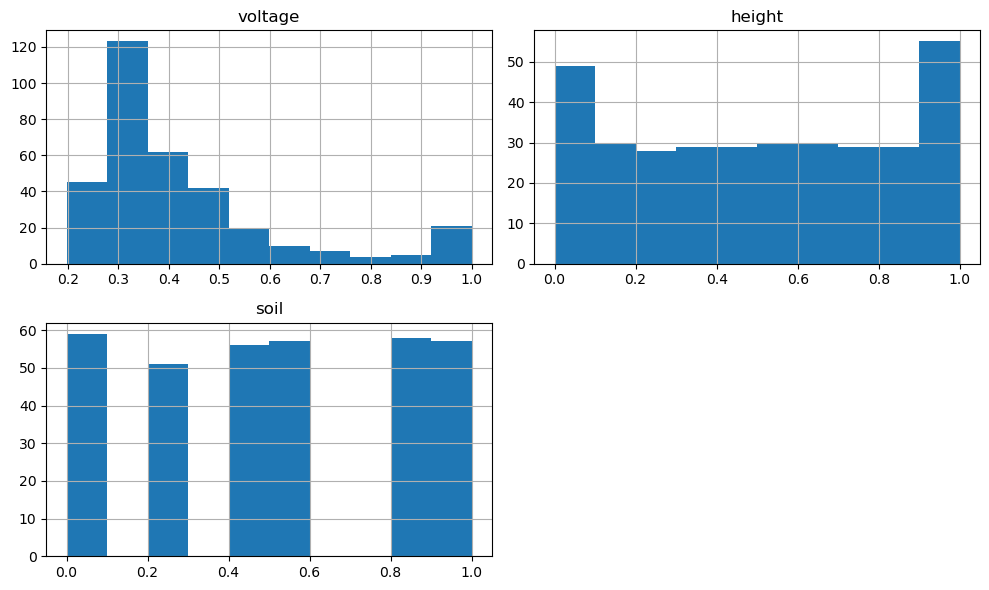

In [8]:
import matplotlib.pyplot as plt

df[["voltage", "height", "soil"]].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(169, 3)
(169, 3)


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

print(accuracies)

[0.40236686390532544, 0.4378698224852071, 0.378698224852071, 0.35502958579881655, 0.3136094674556213, 0.3254437869822485, 0.3136094674556213, 0.3076923076923077, 0.34911242603550297, 0.33727810650887574, 0.35502958579881655, 0.33727810650887574, 0.34911242603550297, 0.3136094674556213, 0.33136094674556216, 0.3431952662721893, 0.3609467455621302, 0.33727810650887574, 0.33727810650887574, 0.3431952662721893]


In [11]:
best_k = accuracies.index(max(accuracies)) + 1

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

Best k: 2
Best accuracy: 0.4378698224852071


I tried values of k from 1 to 20 and calculated the accuracy for each one. I selected the k with the highest accuracy because it performed best on the test set.

In [12]:
best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

In [13]:
confusion_table = pd.crosstab(
    y_test,
    predictions,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion_table

Predicted,1,2,3,4,5
Actual,,,,,
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0


In [14]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.4378698224852071


The best model uses k = 2 and has an overall accuracy of about 43.8%. The model performs much better for mine types 1 and 2 than for the other types. For example, it correctly predicts 25 out of 36 type 1 mines and 32 out of 35 type 2 mines. However, it performs poorly for types 3, 4, and especially type 5. It does not correctly predict any of the type 5 mines. The confusion table also shows that type 5 is often incorrectly predicted as type 1 or type 3.

I would not use this model by itself to make decisions about land mines because its overall accuracy is only about 43.8% and it makes many mistakes for some mine types. In particular, it does not correctly identify any type 5 mines. I would use the model only as an additional tool and have an expert or another method confirm the prediction before taking action. Extra caution should be used for types 3, 4, and 5 because the model has low accuracy for these classes.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 523069e1d6987007f694590e0e2b0037062acc41
- **AI tool and model used:** ChatGPT (GPT-5.6)

### *Prompts used

1. Review my Phase 1 answers for Q1 and Q2. Identify any important mistakes, unclear explanations, or missing information. Give me a concise numbered list of specific changes I should make.

2. Check my k-NN analysis carefully, especially my choice of k, confusion table, accuracy interpretation, and practical advice. Suggest any changes that would make the analysis more accurate and complete.

### *AI-proposed changes


1. Clarify Q1.5 by explaining that repeatedly choosing k based on the test set can overfit to the test set. A validation set or cross-validation is normally preferred for choosing k.

2. Make the confusion-table explanation more specific by explaining that diagonal entries are correct predictions and off-diagonal entries show which classes are confused.

3. In Q2, report the class-specific performance instead of only the overall accuracy. Type 2 performs best (32/35, about 91.4%), while Type 5 performs worst (0/32, 0%).

4. Explain the specific error pattern in the confusion table. Type 5 is most often incorrectly classified as Type 1 (15 cases) or Type 3 (10 cases).

5. Strengthen the practical recommendation by stating that the model should not be used alone for safety-critical decisions because the overall accuracy is only about 43.8% and performance varies greatly across mine types.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I checked the idea of train/test splitting and agreed that using the test set repeatedly to choose k can make the evaluation less independent. A validation set or cross-validation is a better general approach. |
| 2 | Accept | I checked my confusion table and confirmed that the diagonal entries are correct predictions and the off-diagonal entries are errors. |
| 3 | Accept | I calculated the class-specific results directly from my confusion table. Type 2 has 32 correct predictions out of 35, while Type 5 has 0 correct predictions out of 32. |
| 4 | Accept | I verified the Type 5 row of the confusion table. Of the 32 actual Type 5 observations, 15 were predicted as Type 1 and 10 were predicted as Type 3. |
| 5 | Accept | The overall accuracy from my code is 0.4378698, or about 43.8%. The confusion table also shows very different performance across classes, so the model should not be used as the only decision-making tool. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q1

**1. What is the difference between regression and classification?**

Regression is used when we want to predict a numerical value, while classification is used when we want to predict a category or class. For example, predicting the price of a house is regression because the output is a number. Predicting whether an email is spam or not spam is classification because the output is a class.

**2. What is a confusion table? What does it help us understand about a model's performance?**

A confusion table compares the actual classes with the classes predicted by the model. The diagonal entries show correct predictions, while the off-diagonal entries show mistakes and which classes are being confused with each other. This gives us more information than accuracy alone because we can see the specific types of errors the model makes.

**3. What does the SSE quantify about a particular model?**

SSE stands for Sum of Squared Errors. It measures the difference between the actual values and the values predicted by the model by squaring each error and adding them together. A smaller SSE usually means that the predictions are closer to the actual values.

**4. What are overfitting and underfitting?**

Overfitting happens when a model fits the training data too closely, including some of the noise. It may perform very well on the training data but poorly on new data. Underfitting happens when the model is too simple to capture the important patterns in the data, so it may perform poorly even on the training data.

**5. Why split the data into training and testing sets and choose k based on model performance?**

Splitting the data allows us to train the model on one set of observations and evaluate it on observations it has not seen during training. Comparing different values of k helps us find a model that performs well on new data rather than only fitting the training data. However, repeatedly using the final test set to choose k can make the model indirectly fit the test set. A better general approach is to use a validation set or cross-validation to select k and save the test set for the final evaluation.

**6. Class labels vs. probability distributions**

A class label gives one clear prediction, such as "Class 1." It is simple and easy to understand, but it does not show how confident the model is. For example, a model that is 51% confident and one that is 99% confident could give the same class label.

A probability distribution gives a probability for each possible class. This provides more information about uncertainty and can help when some types of mistakes are more important than others. However, probabilities are more complicated to interpret, and predicted probabilities may not always perfectly represent the true probability of each outcome.


In [15]:
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

confusion_table = pd.crosstab(
    y_test,
    predictions,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion_table

Predicted,1,2,3,4,5
Actual,,,,,
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0


The final model has an overall accuracy of about 43.8%. However, the confusion table shows that its performance is very different across mine types. Type 2 performs best, with 32 out of 35 observations correctly classified, or about 91.4%. Type 1 also performs relatively well, with 25 out of 36 correctly classified, or about 69.4%.

The model performs much worse for Types 3, 4, and 5. Type 3 has 9 out of 33 correct predictions (about 27.3%), and Type 4 has 8 out of 33 (about 24.2%). Type 5 performs worst because none of its 32 observations are correctly classified. Type 5 is especially likely to be confused with Type 1 (15 cases) or Type 3 (10 cases).

Because of these errors, I would not use this model by itself to make real decisions about land mines. The overall accuracy is fairly low, and completely missing Type 5 could be especially concerning in a real-world setting. I would use the model only as an additional source of information and have an expert or another method confirm the prediction before taking action. I would be especially cautious with Types 3, 4, and 5 because the model performs poorly for these classes.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]